# Data Preprocessing
Performer: Tùng Nguyễn (AE - Data)

## Exploratory Data Analysis Findings

### Missing Values

Several variables contained missing observations. Numerical features were imputed using median values, while Balcony and Car Parking were imputed with zero. Missing target values were removed from the dataset.

### Outlier Analysis

Price, Amount, Carpet Area, and Super Area exhibited right-skewed distributions with several extreme observations. Most extreme values appear to represent premium properties rather than data-entry errors. Car Parking contained exceptionally large values (up to 999), which were treated as outliers and clipped before modeling.

### Numerical Features

Property size variables, including Carpet Area and Super Area, show positive relationships with property price. Larger properties generally command higher prices.

The number of bathrooms also tends to increase with property value, suggesting that larger and more expensive homes typically contain more amenities.

### Location Effects

Property prices vary substantially across locations. Premium locations consistently exhibit higher median prices, indicating that geographic location is one of the strongest determinants of housing value.

### Property Characteristics

Furnishing status, ownership type, property facing direction, and overlooking characteristics all show differences in price distributions. Certain categories are associated with higher median prices, suggesting that these features contribute additional value beyond property size alone.

### Overall Findings

The housing market demonstrates strong heterogeneity across locations and property characteristics. Property size, location, and quality-related features appear to be the most influential factors affecting housing prices and are expected to play important roles in predictive modeling.


## Data Preprocessing & EDA Summary

### Data Cleaning

* Converted Carpet Area and Super Area into numerical values.
* Standardized Amount(in rupees) into a consistent rupee format.
* Extracted numerical information from Bathroom, Balcony, and Car Parking.

### Missing Value Treatment

* Removed rows with missing target values (Price).
* Filled missing numerical features using median values.
* Filled missing Balcony and Car Parking values with 0.
* Replaced missing categorical values with "Unknown" when necessary.

### Outlier Analysis

* Detected outliers using descriptive statistics and boxplots.
* Price, Amount, and Area features showed right-skewed distributions.
* Car Parking contained extreme values (e.g., 999), which were clipped at the 99th percentile to reduce their impact.

### Exploratory Data Analysis

* Property size (Carpet Area and Super Area) shows a positive relationship with price.
* Location is one of the strongest factors influencing property value.
* Furnishing, Ownership, Transaction, Facing, and Overlooking categories exhibit noticeable differences in median prices.
* Premium property characteristics generally correspond to higher prices.

### Key Insights

* Larger properties tend to have higher prices.
* Property location significantly affects valuation.
* Property characteristics provide additional predictive information beyond size.
* The cleaned dataset is suitable for predictive modeling using Linear Regression.

# Coding Space

In [51]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import re
import os

In [52]:
from sklearn.impute import SimpleImputer
from pathlib import Path

In [53]:
data_path = Path("../data/raw/data.csv")

df = pd.read_csv(data_path)
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


Quick Note 1:
+ Expected Numerical Columns (main value): Amount, Price, Area(s), Bathrooms, Balcony, Car Parking
+ Lac = 1e5, 1 Cr = 1e7

In [54]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isnull().sum(),
    "missing_pct": round(df.isnull().mean()*100, 2),
    "unique": df.nunique()
})

summary

,dtype,missing,missing_pct,unique
Index,int64,0,0.00,187531
Title,str,0,0.00,32446
Description,str,3023,1.61,65634
Amount(in rupees),str,0,0.00,1561
Price (in rupees),float64,17665,9.42,10958
location,str,0,0.00,81
Carpet Area,str,80673,43.02,2758
Status,str,615,0.33,1
Floor,str,7077,3.77,947
Transaction,str,83,0.04,4


Quick Note 2: 
+ Expected Numerical Columns are Categorical: Amount, Area, Bathroom, Balcony, Car Parking
+ Drop Index, Title, Description, Status, Society, Dimensions, Plot Area, Dimensions, Floor

In [55]:
cols_drop = [
    "Index",
    "Title",
    "Description",
    "Status",
    "Society",
    "Dimensions",
    "Plot Area",
    "Floor"
]

First Filtered Dataframe

In [56]:
filtered_df_1 = df.copy()
filtered_df_1 = filtered_df_1.drop(columns=cols_drop)

In [57]:
# Area Convert
for col in ["Carpet Area", "Super Area"]:

    filtered_df_1[col] = (
        filtered_df_1[col]
        .astype(str)
        .str.extract(r"([\d.]+)")
        .astype(float)
    )

In [58]:
# Amount Convert
def convert_amount(x):

    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    m = re.search(r"([\d.]+)", x)

    if m is None:
        return np.nan

    value = float(m.group(1))

    if "lac" in x.lower():
        return value * 1e5

    if "cr" in x.lower():
        return value * 1e7

    return value


filtered_df_1["Amount(in rupees)"] = (
    filtered_df_1["Amount(in rupees)"]
    .apply(convert_amount)
)

In [59]:
# Bathroom/Balcony/Parking Convert
def extract_numeric_feature(x):

    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    match = re.search(r"(\d+)", x)

    if match is None:
        return np.nan

    value = int(match.group(1))

    if ">" in x:
        return value + 1

    return value

for col in ["Bathroom", "Balcony", "Car Parking"]:

    filtered_df_1[col] = (
        filtered_df_1[col]
        .apply(extract_numeric_feature)
    )

In [60]:
# Load new Dataframe
filtered_df_1.head()

,Amount(in rupees),Price (in rupees),location,Carpet Area,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Car Parking,Ownership,Super Area
0,4200000.0,6000.0,thane,500.0,Resale,Unfurnished,NaN,NaN,1.0,2.0,NaN,NaN,NaN
1,9800000.0,13799.0,thane,473.0,Resale,Semi-Furnished,East,Garden/Park,2.0,NaN,1.0,Freehold,NaN
2,14000000.0,17500.0,thane,779.0,Resale,Unfurnished,East,Garden/Park,2.0,NaN,1.0,Freehold,NaN
3,2500000.0,NaN,thane,530.0,Resale,Unfurnished,NaN,NaN,1.0,1.0,NaN,NaN,NaN
4,16000000.0,18824.0,thane,635.0,Resale,Unfurnished,West,"Garden/Park, Main Road",2.0,NaN,1.0,Co-operative Society,NaN


In [61]:
summary = pd.DataFrame({
    "dtype": filtered_df_1.dtypes,
    "missing": filtered_df_1.isnull().sum(),
    "missing_pct": round(filtered_df_1.isnull().mean()*100, 2),
    "unique": filtered_df_1.nunique()
})

summary

,dtype,missing,missing_pct,unique
Amount(in rupees),float64,9684,5.16,1559
Price (in rupees),float64,17665,9.42,10958
location,str,0,0.00,81
Carpet Area,float64,80673,43.02,2473
Transaction,str,83,0.04,4
Furnishing,str,2897,1.54,3
facing,str,70233,37.45,8
overlooking,str,81436,43.43,19
Bathroom,float64,828,0.44,11
Balcony,float64,48935,26.09,11


Quick Note 3:
+ Price = Target
+ Numerical Features (Amount, Area, Bathroom): Median
+ Numerical Features (Balcony, Car Parking): fillna(0)
+ Categorical Features: Unknown

Second Filtered Dataframe

In [62]:
filtered_df_2 = filtered_df_1.copy()

filtered_df_2 = filtered_df_2.dropna(
    subset=["Price (in rupees)"]
)

In [63]:
median_cols = [
    "Amount(in rupees)",
    "Carpet Area",
    "Super Area",
    "Bathroom"
]

for col in median_cols:

    filtered_df_2[col] = (
        filtered_df_2[col]
        .fillna(filtered_df_2[col].median())
    )

In [64]:
zero_fill_cols = [
    "Balcony",
    "Car Parking"
]

for col in zero_fill_cols:

    filtered_df_2[col] = (
        filtered_df_2[col]
        .fillna(0)
    )

In [65]:
categorical_cols = [
    "location",
    "Transaction",
    "Furnishing",
    "facing",
    "overlooking",
    "Ownership"
]

for col in categorical_cols:

    filtered_df_2[col] = (
        filtered_df_2[col]
        .fillna("Unknown")
    )

In [66]:
filtered_df_2.info()

<class 'pandas.DataFrame'>
Index: 169866 entries, 0 to 187530
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Amount(in rupees)  169866 non-null  float64
 1   Price (in rupees)  169866 non-null  float64
 2   location           169866 non-null  str    
 3   Carpet Area        169866 non-null  float64
 4   Transaction        169866 non-null  str    
 5   Furnishing         169866 non-null  str    
 6   facing             169866 non-null  str    
 7   overlooking        169866 non-null  str    
 8   Bathroom           169866 non-null  float64
 9   Balcony            169866 non-null  float64
 10  Car Parking        169866 non-null  float64
 11  Ownership          169866 non-null  str    
 12  Super Area         169866 non-null  float64
dtypes: float64(7), str(6)
memory usage: 18.1 MB


Outlier Analysis

In [67]:
num_cols = [
    "Price (in rupees)",
    "Amount(in rupees)",
    "Carpet Area",
    "Super Area",
    "Bathroom",
    "Balcony",
    "Car Parking"
]

filtered_df_2[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Price (in rupees),169866.0,7.583772e+03,2.724171e+04,0.0,4297.0,6034.0,9450.0,6.700000e+06
Amount(in rupees),169866.0,1.198659e+07,4.025091e+07,100000.0,5000000.0,7800000.0,14500000.0,1.400300e+10
Carpet Area,169866.0,1.139734e+03,2.392272e+03,1.0,1000.0,1050.0,1140.0,7.092220e+05
Super Area,169866.0,1.280274e+03,4.552496e+02,1.0,1255.0,1255.0,1255.0,9.450000e+03
Bathroom,169866.0,2.444556e+00,8.493517e-01,1.0,2.0,2.0,3.0,1.100000e+01
Balcony,169866.0,1.494095e+00,1.218744e+00,0.0,0.0,1.0,2.0,1.100000e+01
Car Parking,169866.0,1.864811e+00,2.159650e+01,0.0,0.0,0.0,1.0,9.990000e+02


Quick note 4:
+ Outlier: Car Parking (Mean, Median << Max)

In [68]:
filtered_df_2["Car Parking"].describe(
    percentiles=[0.9, 0.95, 0.99]
)

count    169866.000000
mean          1.864811
std          21.596500
min           0.000000
90%           2.000000
95%           2.000000
99%          10.000000
max         999.000000
Name: Car Parking, dtype: float64

In [69]:
filtered_df_2["Car Parking"].nlargest(50)

83932     999.0
160316    908.0
52152     903.0
166051    901.0
155338    835.0
82443     818.0
148020    804.0
145278    801.0
169875    801.0
16921     706.0
52404     704.0
144710    703.0
166019    703.0
187356    702.0
68        701.0
51854     701.0
146637    701.0
144948    605.0
154904    605.0
51987     604.0
169861    604.0
40166     601.0
168447    601.0
181975    601.0
92045     571.0
40152     536.0
1472      509.0
172281    509.0
144890    507.0
161484    506.0
163142    506.0
2123      505.0
70036     505.0
114614    505.0
149081    505.0
150543    504.0
3984      503.0
144788    503.0
147863    503.0
173270    503.0
70437     502.0
5128      501.0
50724     500.0
160672    500.0
16081     442.0
166870    420.0
184467    416.0
184816    416.0
71274     413.0
83286     411.0
Name: Car Parking, dtype: float64

In [70]:
df.loc[83932, "Car Parking"]

'999 Covered'

Car Parking contains extreme values ranging up to 999, while 99% of observations are below or equal to 10. These observations are likely special encodings or highly unusual cases and should be treated as outliers.

In [71]:
filtered_df_2["Car Parking"] = (
    filtered_df_2["Car Parking"]
    .clip(upper=10)
)

EDA

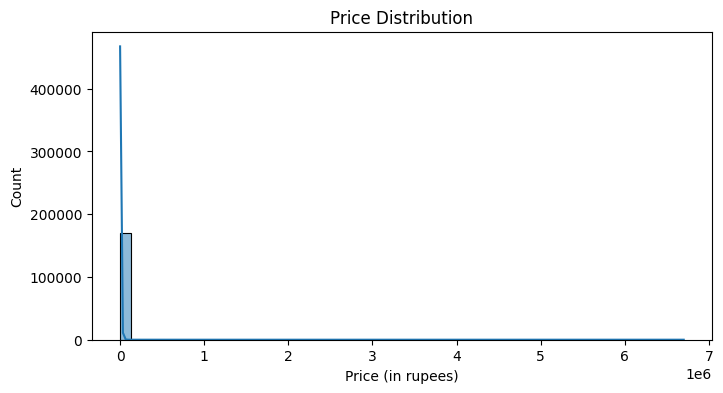

In [72]:
plt.figure(figsize=(8, 4))

sns.histplot(
    filtered_df_2["Price (in rupees)"],
    bins=50,
    kde=True
)

plt.title("Price Distribution")

plt.show()

Quick Note 5: Most of the value is < 0.2 * 1e6

In [73]:
corr = filtered_df_2.select_dtypes(
    include=["number"]
).corr()

corr["Price (in rupees)"] \
    .sort_values(ascending=False)

Price (in rupees)    1.000000
Amount(in rupees)    0.762790
Bathroom             0.061342
Balcony              0.035028
Car Parking          0.024790
Super Area           0.014033
Carpet Area          0.009468
Name: Price (in rupees), dtype: float64

Numerical Correlation

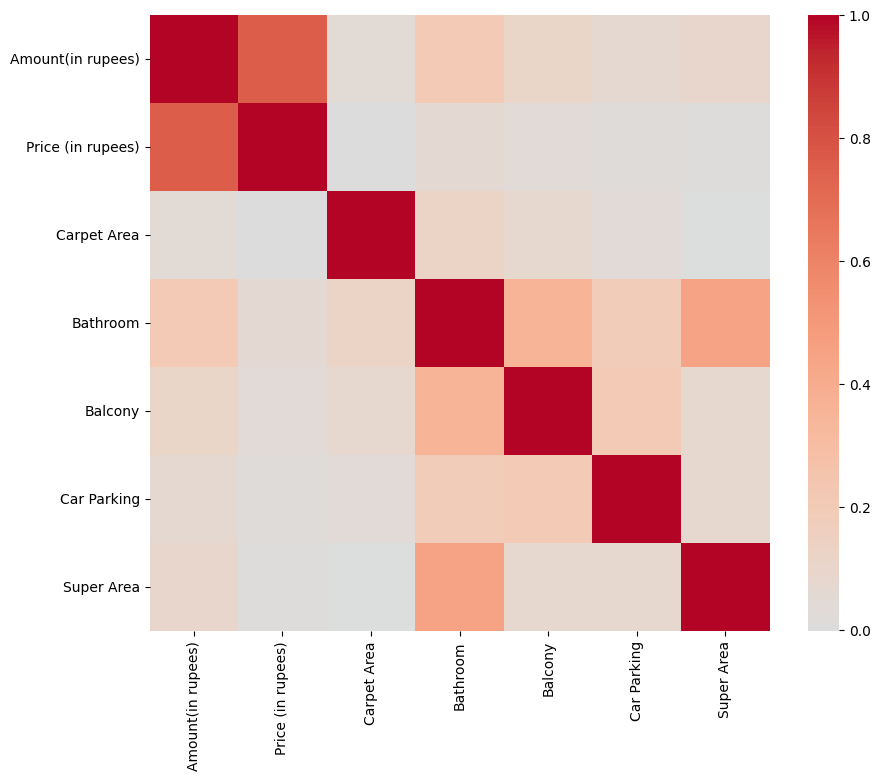

In [74]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.show()

Categorical Features vs Price

In [75]:
top_only_cols = [
    "location",
    "overlooking"
]

boxplot_cols = [
    "Transaction",
    "Furnishing",
    "facing",
    "Ownership"
]

In [76]:
for col in top_only_cols:

    print(f"\n{'=' * 60}")
    print(f"Top 5 {col} by Median Price")

    summary = (
        filtered_df_2
        .groupby(col)["Price (in rupees)"]
        .median()
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
    )

    display(summary)


Top 5 location by Median Price


,location,Price (in rupees)
0,mumbai,20909.0
1,new-delhi,10667.0
2,thane,9820.0
3,navi-mumbai,8824.0
4,gurgaon,8706.5



Top 5 overlooking by Median Price


,overlooking,Price (in rupees)
0,Pool,15249.0
1,"Pool, Main Road, Garden/Park",11328.0
2,"Main Road, Garden/Park",9836.0
3,"Garden/Park, Main Road",9631.0
4,"Main Road, Garden/Park, Pool",8000.0


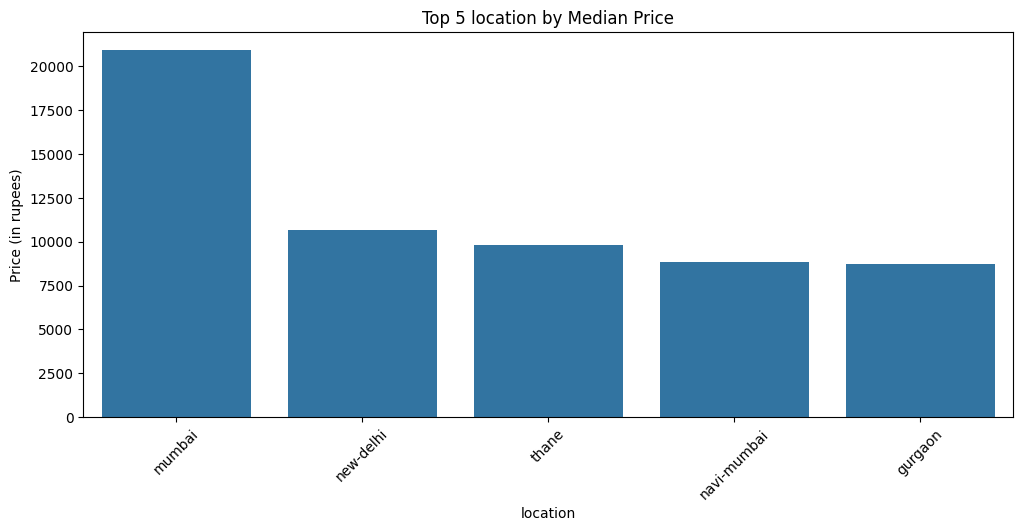

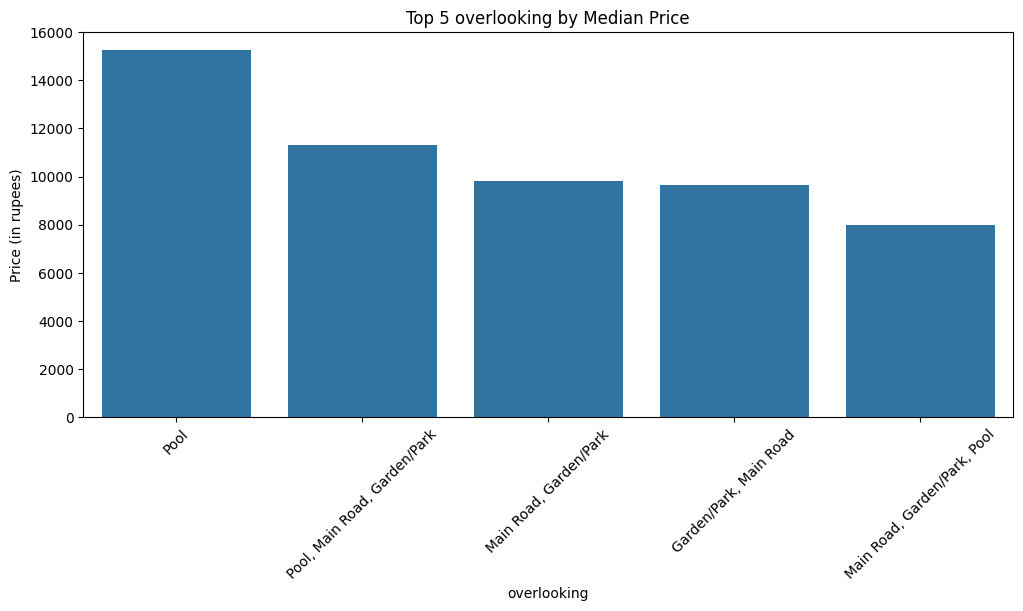

In [77]:
for col in top_only_cols:

    summary = (
        filtered_df_2
        .groupby(col)["Price (in rupees)"]
        .median()
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
    )

    plt.figure(figsize=(12, 5))

    sns.barplot(
        data=summary,
        x=col,
        y="Price (in rupees)"
    )

    plt.title(
        f"Top 5 {col} by Median Price"
    )

    plt.xticks(rotation=45)

    plt.show()

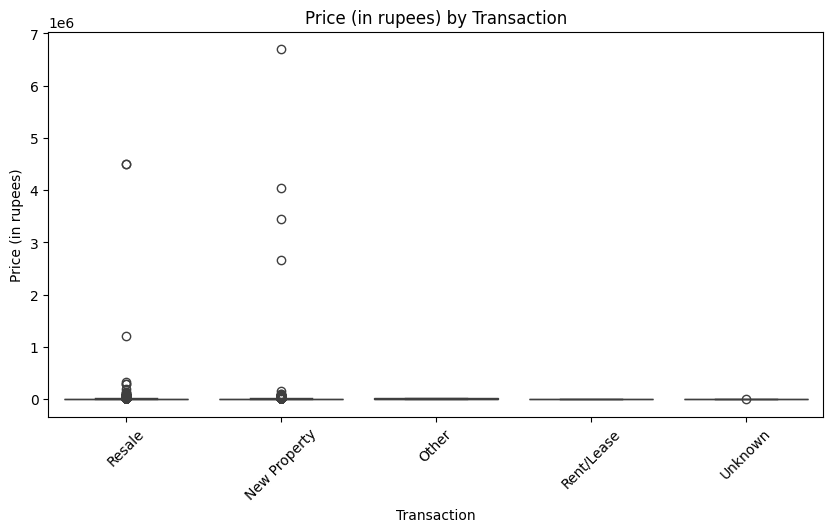

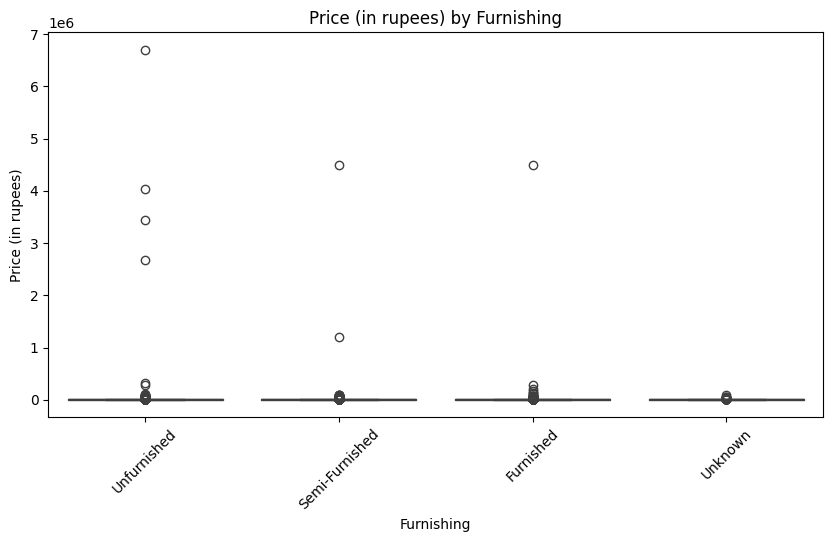

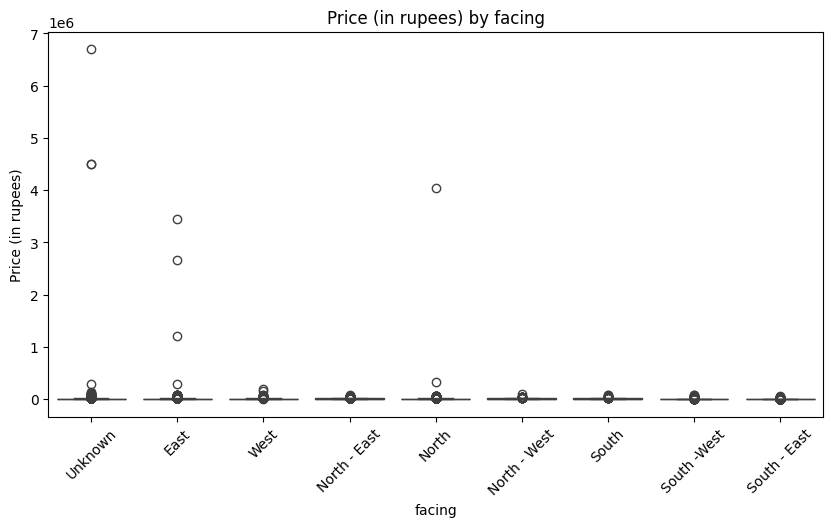

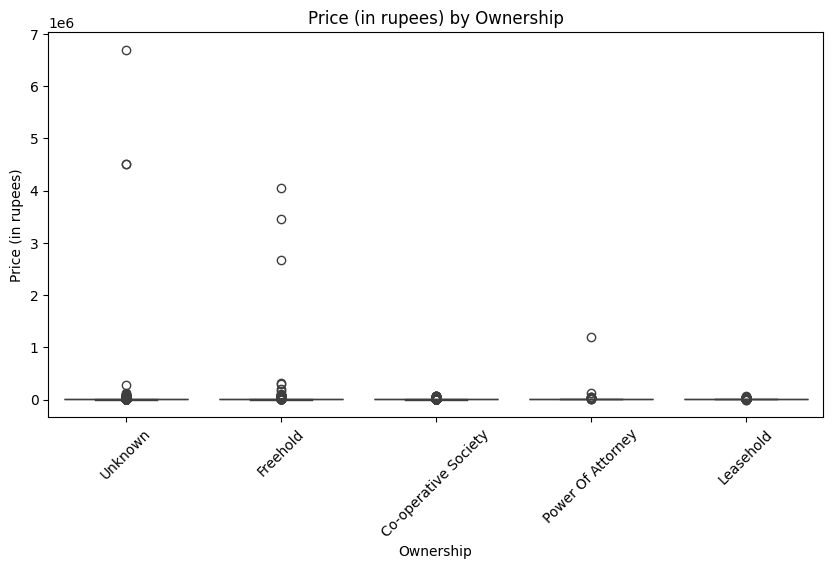

In [78]:
for col in boxplot_cols:

    plt.figure(figsize=(10, 5))

    sns.boxplot(
        data=filtered_df_2,
        x=col,
        y="Price (in rupees)"
    )

    plt.title(
        f"{"Price (in rupees)"} by {col}"
    )

    plt.xticks(rotation=45)

    plt.show()